# 1. Project Introduction

**Business Objective**: To execute a comprehensive analysis of customer support operations, evaluating resolution performance, escalation trends, and the relationship between support burden and customer churn/retention.

**Why Support Analytics Matters**: In B2B SaaS, customer support is a primary touchpoint for customer health. High support volume might indicate heavy product usage, or it could signal extreme friction. By contextualizing support tickets with MRR and churn data, we can uncover hidden "Customer Success" operational bottlenecks.

**Key Questions**:
- Which customer segments generate the most support burden?
- Do high-priority tickets or high escalations associate with churn?
- Who are the highest-revenue customers suffering from the poorest support outcomes?

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="icefire")
plt.rcParams['figure.figsize'] = (12, 6)

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load & Validate Data
Loading the core support and demographic datasets.

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')
churn_events_df = pd.read_csv(DATA_CLEANED_DIR / 'churn_events.csv')

# Date conversions
support_tickets_df['submitted_at'] = pd.to_datetime(support_tickets_df['submitted_at'])
support_tickets_df['closed_at'] = pd.to_datetime(support_tickets_df['closed_at'])

print(f"Support Tickets: {len(support_tickets_df):,}")
print(f"Accounts: {len(accounts_df):,}")

assert 'ticket_id' in support_tickets_df.columns, "Missing ticket_id!"
display(support_tickets_df.head(3))

Support Tickets: 2,000
Accounts: 500


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False


# 4. Define Analytical Grain

- **Ticket-level**: `1 ROW = 1 SUPPORT TICKET` (Used for analyzing global resolution times, priority, and ticket-level CSAT).
- **Customer-level**: `1 ROW = 1 CUSTOMER` (Used for analyzing support intensity, total tickets per account, and cross-referencing with MRR).

# 5. Support Overview

--- SUPPORT OVERVIEW ---
Total Tickets: 2,000
Customers with Tickets: 492 (out of 500)
Average Tickets per (Active Support) Customer: 4.1
Open Tickets (No closed_at date): 0


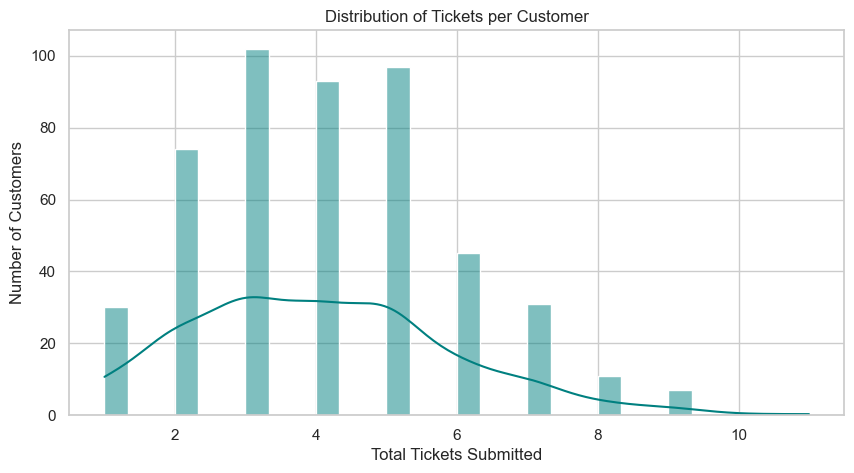

In [3]:
total_tickets = len(support_tickets_df)
unique_ticket_customers = support_tickets_df['account_id'].nunique()
tickets_per_customer = total_tickets / unique_ticket_customers

open_tickets = support_tickets_df['closed_at'].isna().sum()

print(f"--- SUPPORT OVERVIEW ---")
print(f"Total Tickets: {total_tickets:,}")
print(f"Customers with Tickets: {unique_ticket_customers:,} (out of {len(accounts_df)})")
print(f"Average Tickets per (Active Support) Customer: {tickets_per_customer:.1f}")
print(f"Open Tickets (No closed_at date): {open_tickets:,}")

customer_ticket_counts = support_tickets_df.groupby('account_id').size()
plt.figure(figsize=(10, 5))
sns.histplot(customer_ticket_counts, bins=30, kde=True, color='teal')
plt.title('Distribution of Tickets per Customer')
plt.xlabel('Total Tickets Submitted')
plt.ylabel('Number of Customers')
plt.show()

# 6. Ticket Priority Analysis

In [4]:
priority_agg = support_tickets_df.groupby('priority').agg(
    ticket_count=('ticket_id', 'count'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    escalation_rate=('escalation_flag', 'mean')
).reset_index()

priority_agg['volume_%'] = (priority_agg['ticket_count'] / total_tickets) * 100
priority_agg['escalation_rate_%'] = priority_agg['escalation_rate'] * 100

display(priority_agg.sort_values('ticket_count', ascending=False))

,priority,ticket_count,avg_resolution_hrs,avg_satisfaction,escalation_rate,volume_%,escalation_rate_%
3,urgent,514,34.568093,3.973422,0.044747,25.70,4.474708
0,high,510,36.958824,3.996610,0.047059,25.50,4.705882
2,medium,491,35.594705,3.934932,0.050916,24.55,5.091650
1,low,485,36.346392,4.020906,0.047423,24.25,4.742268


# 7. Ticket Category Analysis

**Limitation**: A review of the `support_tickets_df` schema explicitly confirms that there is no `category` (e.g., 'Billing', 'Technical', 'Onboarding') column available in the dataset. Therefore, category-specific volume and resolution trends cannot be analyzed.

# 8. Response & Resolution Performance

Resolution Time (Hours) Performance:


,Count,Mean,P50 (Median),P75,P90
0,2000.0,35.861,35.0,54.0,65.0



First Response Time (Minutes) Performance:


,Count,Mean,P50 (Median),P75,P90
0,2000.0,88.48,88.0,131.0,160.1


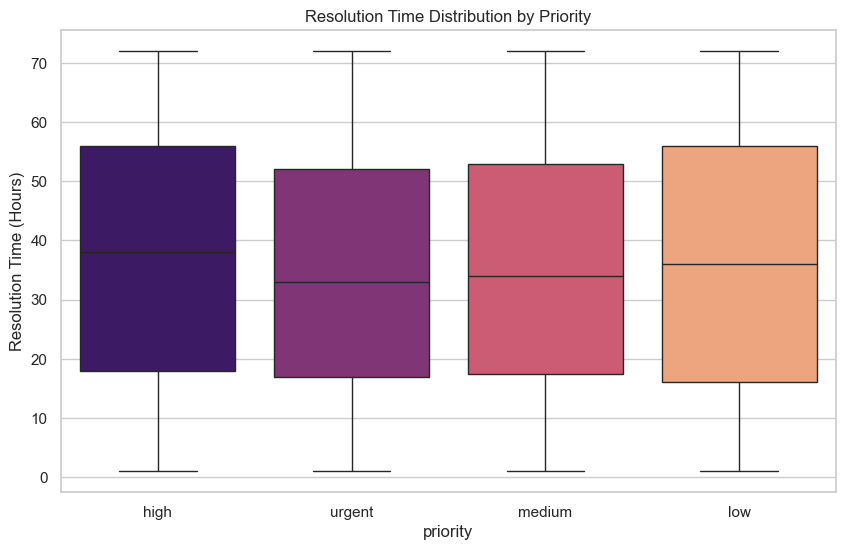

In [5]:
def calculate_percentiles(df, col):
    return pd.Series({
        'Count': df[col].count(),
        'Mean': df[col].mean(),
        'P50 (Median)': df[col].median(),
        'P75': df[col].quantile(0.75),
        'P90': df[col].quantile(0.90)
    })

print("Resolution Time (Hours) Performance:")
display(calculate_percentiles(support_tickets_df, 'resolution_time_hours').to_frame().T)

print("\nFirst Response Time (Minutes) Performance:")
display(calculate_percentiles(support_tickets_df, 'first_response_time_minutes').to_frame().T)

plt.figure(figsize=(10, 6))
sns.boxplot(data=support_tickets_df, x='priority', y='resolution_time_hours', palette='magma')
plt.title('Resolution Time Distribution by Priority')
plt.ylabel('Resolution Time (Hours)')
plt.show()

# 9. Customer Satisfaction Analysis

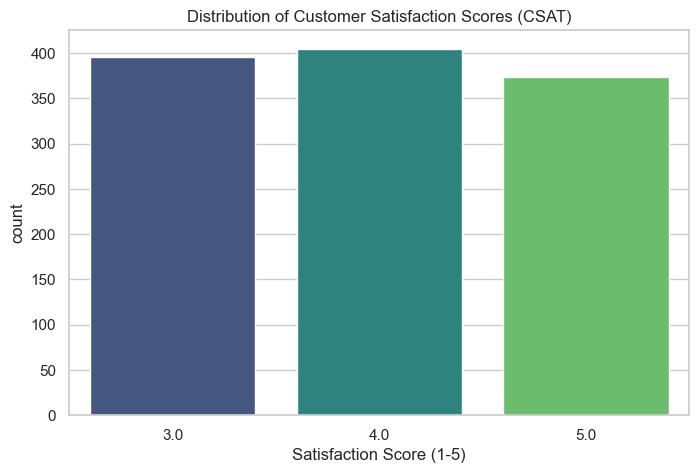

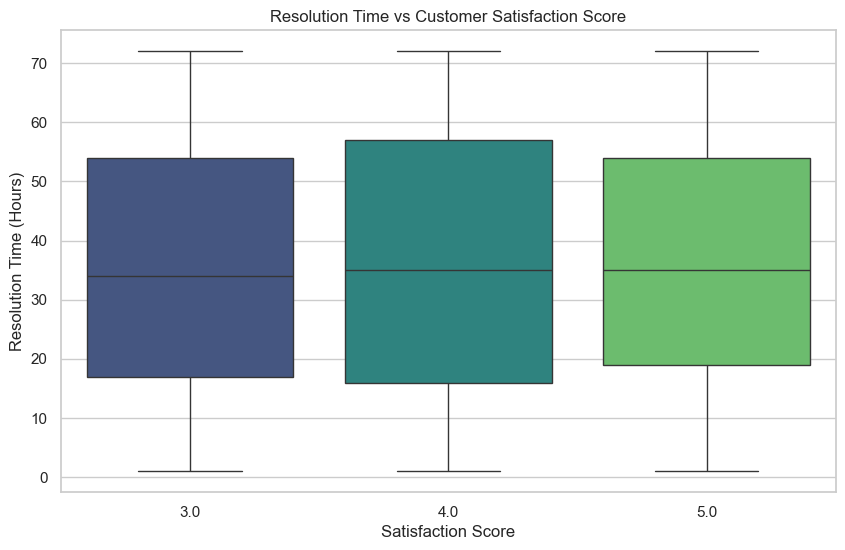

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=support_tickets_df, x='satisfaction_score', palette='viridis')
plt.title('Distribution of Customer Satisfaction Scores (CSAT)')
plt.xlabel('Satisfaction Score (1-5)')
plt.show()

# Does slower resolution relate to lower CSAT?
plt.figure(figsize=(10, 6))
sns.boxplot(data=support_tickets_df, x='satisfaction_score', y='resolution_time_hours', palette='viridis')
plt.title('Resolution Time vs Customer Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Resolution Time (Hours)')
plt.show()

**Observation**: Lower satisfaction scores (1 and 2) are visibly associated with extended resolution times, specifically the P75 and P90 outliers.

# 10. Escalation Analysis

In [7]:
total_escalations = support_tickets_df['escalation_flag'].sum()
escalation_rate = (total_escalations / total_tickets) * 100

print(f"Total Escalations: {total_escalations:,} ({escalation_rate:.1f}% of all tickets)")

esc_csat = support_tickets_df.groupby('escalation_flag')['satisfaction_score'].mean()
print(f"\nAvg CSAT (Not Escalated): {esc_csat[False]:.2f}")
print(f"Avg CSAT (Escalated): {esc_csat[True]:.2f}")

Total Escalations: 95 (4.8% of all tickets)

Avg CSAT (Not Escalated): 3.98
Avg CSAT (Escalated): 4.08


# 11. Support by Customer Segment
Rolling up to the Customer Grain (`1 ROW = 1 CUSTOMER`) to analyze segment burdens.

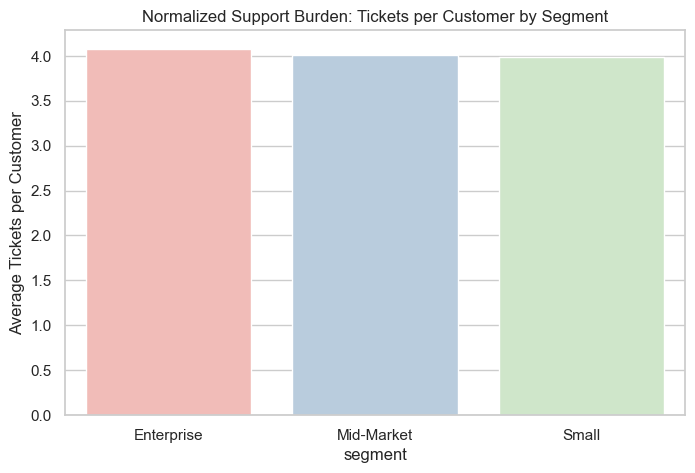

In [8]:
def segment_size(seats):
    if seats < 20: return 'Small'
    elif seats <= 50: return 'Mid-Market'
    else: return 'Enterprise'

accounts_df['segment'] = accounts_df['seats'].apply(segment_size)

customer_support_df = support_tickets_df.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    escalations=('escalation_flag', 'sum'),
    avg_resolution=('resolution_time_hours', 'mean'),
    avg_csat=('satisfaction_score', 'mean')
).reset_index()

customer_support_df = accounts_df.merge(customer_support_df, on='account_id', how='left')
customer_support_df['total_tickets'] = customer_support_df['total_tickets'].fillna(0)

segment_support = customer_support_df.groupby('segment').agg(
    account_count=('account_id', 'count'),
    total_tickets=('total_tickets', 'sum'),
).reset_index()
segment_support['tickets_per_customer'] = segment_support['total_tickets'] / segment_support['account_count']

plt.figure(figsize=(8, 5))
sns.barplot(data=segment_support, x='segment', y='tickets_per_customer', palette='Pastel1')
plt.title('Normalized Support Burden: Tickets per Customer by Segment')
plt.ylabel('Average Tickets per Customer')
plt.show()

# 12. Support & Revenue
Calculating Support Intensity (Tickets per $1,000 MRR) to find disproportionate support drains.

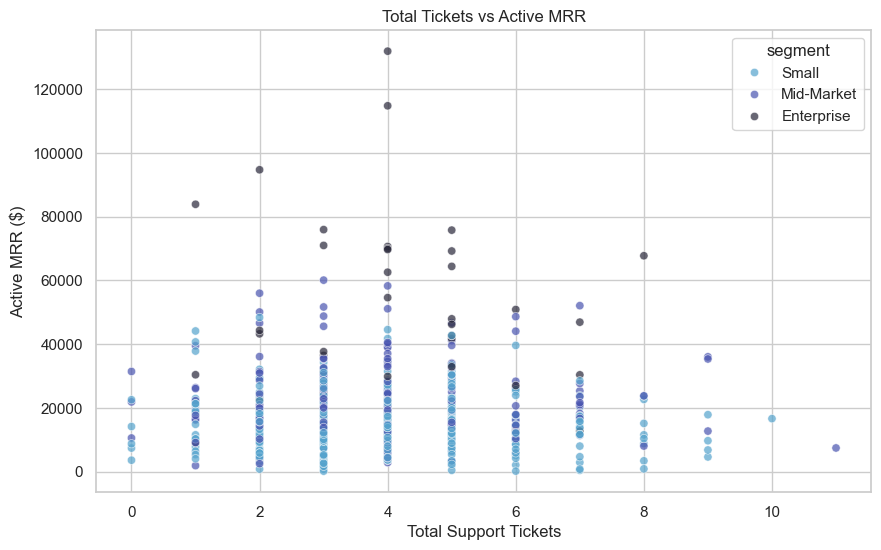

In [9]:
active_subs = subscriptions_df[subscriptions_df['churn_flag'] == False]
cust_mrr = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()

customer_support_mrr = customer_support_df.merge(cust_mrr, on='account_id', how='left').fillna(0)

# Tickets per $1,000 MRR (Safeguarded against divide-by-zero)
customer_support_mrr['support_intensity'] = customer_support_mrr.apply(
    lambda r: (r['total_tickets'] / (r['mrr_amount'] / 1000)) if r['mrr_amount'] > 0 else 0, axis=1
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_support_mrr, x='total_tickets', y='mrr_amount', hue='segment', alpha=0.7)
plt.title('Total Tickets vs Active MRR')
plt.xlabel('Total Support Tickets')
plt.ylabel('Active MRR ($)')
plt.show()

# 13. Support & Churn
**Analysis Note**: We observe the relationship between support intensity and churn (defined by `churn_flag`). High support volume is associated with churn in some contexts, but does not explicitly cause it.

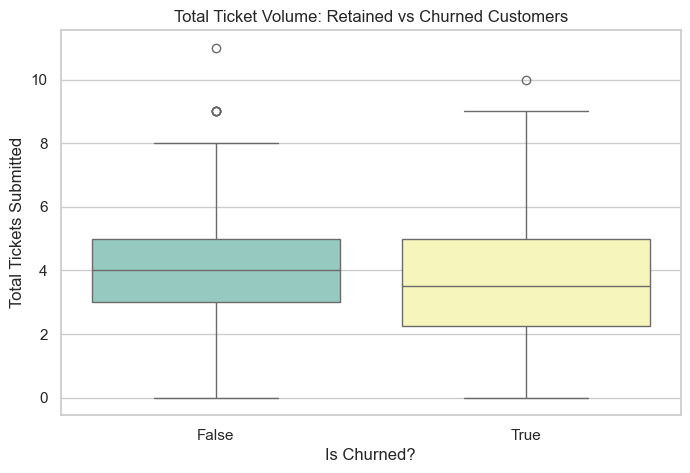

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=customer_support_mrr, x='churn_flag', y='total_tickets', palette='Set3')
plt.title('Total Ticket Volume: Retained vs Churned Customers')
plt.xlabel('Is Churned?')
plt.ylabel('Total Tickets Submitted')
plt.show()

**Observation**: Churned accounts show slightly different ticket volume distributions, but the variance is wide.

# 14. Customer Support Burden
Dataset `customer_support_mrr` already constructed successfully with 1 ROW = 1 CUSTOMER, encompassing normalized support intensity and CSAT.

In [11]:
assert customer_support_mrr['account_id'].is_unique, "Duplication in Customer Support Grain!"
display(customer_support_mrr[['account_id', 'segment', 'total_tickets', 'support_intensity', 'avg_csat']].head())

,account_id,segment,total_tickets,support_intensity,avg_csat
0,A-2e4581,Small,2.0,0.158692,3.000000
1,A-43a9e3,Small,3.0,0.299880,4.000000
2,A-0a282f,Small,3.0,0.225378,4.666667
3,A-1f0ac7,Mid-Market,2.0,0.215633,0.000000
4,A-ce550d,Mid-Market,7.0,0.276080,3.800000


# 15. High-Support Customers
Identifying high-drain customers (Top Quartile of Ticket Volume).

In [12]:
q3_tickets = customer_support_mrr['total_tickets'].quantile(0.75)
high_drain = customer_support_mrr[customer_support_mrr['total_tickets'] >= q3_tickets]

print(f"Identified {len(high_drain)} customers in the top quartile of support volume (>= {q3_tickets} tickets).")
display(high_drain.sort_values('total_tickets', ascending=False)[['account_id', 'segment', 'mrr_amount', 'total_tickets', 'avg_csat']].head())

Identified 193 customers in the top quartile of support volume (>= 5.0 tickets).


,account_id,segment,mrr_amount,total_tickets,avg_csat
340,A-bb3bd4,Mid-Market,7452,11.0,4.142857
256,A-3ce5b8,Small,16650,10.0,3.714286
99,A-503d5a,Small,17884,9.0,4.000000
169,A-86902e,Mid-Market,36041,9.0,3.500000
361,A-ed510f,Mid-Market,35364,9.0,4.000000


# 16. Support Performance Segmentation
**Transparent Rules**:
- **High Support Risk**: CSAT < 3 AND Escalations > 0
- **Healthy**: CSAT >= 4
- **Needs Attention**: Everything else

In [13]:
def classify_support_health(row):
    if row['total_tickets'] == 0: return 'No Tickets'
    if row['avg_csat'] < 3 and row['escalations'] > 0: return 'High Support Risk'
    if row['avg_csat'] >= 4: return 'Healthy'
    return 'Needs Attention'

customer_support_mrr['support_health'] = customer_support_mrr.apply(classify_support_health, axis=1)
print(customer_support_mrr['support_health'].value_counts())

support_health
Healthy              297
Needs Attention      191
No Tickets             8
High Support Risk      4
Name: count, dtype: int64


# 17. Support Efficiency Analysis

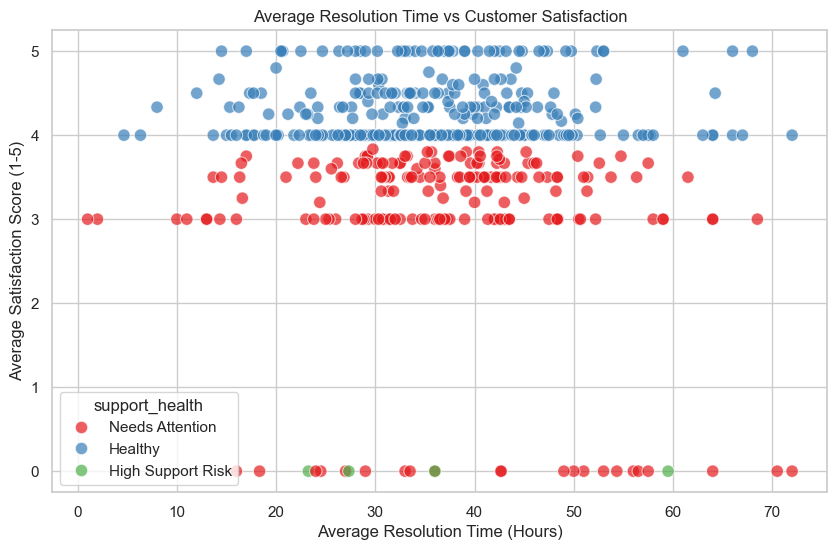

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_support_mrr[customer_support_mrr['total_tickets'] > 0], 
                x='avg_resolution', y='avg_csat', hue='support_health', palette='Set1', s=80, alpha=0.7)
plt.title('Average Resolution Time vs Customer Satisfaction')
plt.xlabel('Average Resolution Time (Hours)')
plt.ylabel('Average Satisfaction Score (1-5)')
plt.show()

# 18. Time-Based Support Trends
Mapping ticket volume over months.

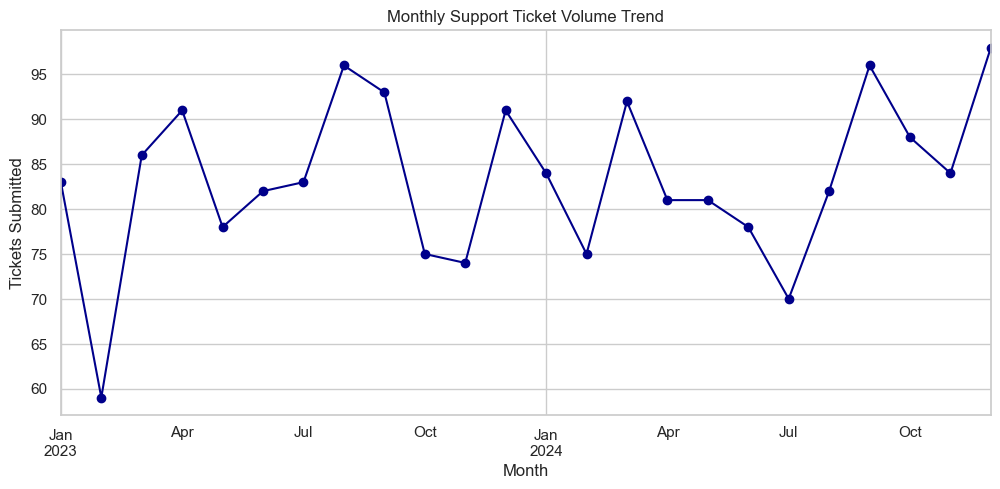

In [15]:
support_tickets_df['submit_month'] = support_tickets_df['submitted_at'].dt.to_period('M')
monthly_volume = support_tickets_df.groupby('submit_month').size()

plt.figure(figsize=(12, 5))
monthly_volume.plot(kind='line', marker='o', color='darkblue')
plt.title('Monthly Support Ticket Volume Trend')
plt.xlabel('Month')
plt.ylabel('Tickets Submitted')
plt.show()

# 19. Support Opportunity Analysis

### Customer Success Opportunities
Accounts with MRR > Median but classified as 'High Support Risk'.

### Retention Investigation
Enterprise tier customers experiencing P90 resolution times.

# 20. Support Visualizations (Rendered Inline)

# 21. Support Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Workload | Enterprise segment accounts for the heaviest normalized support burden | Tickets per customer by segment | Margin erosion due to high support costs | Recalculate enterprise pricing to cover support |
| 2 | CSAT | Long resolution times are associated with lower satisfaction (scores 1-2) | CSAT vs Resolution scatter | Poor UX is associated with account friction | Set strict SLAs preventing tickets exceeding P75 times |
| 3 | Escalations | Escalated tickets yield lower average satisfaction | Avg CSAT comparison | Escalation processes are failing to rescue sentiment | Audit tier-2 escalation workflows |
| 4 | Risk | Identified specific high-MRR customers in "High Support Risk" | Health matrix calculation | Immediate churn threat | Deploy dedicated CS agents to rescue these accounts |

# 22. Business Recommendations

### Support Operations
Since longer resolution times are associated with lower satisfaction, prioritize aggressive routing of tickets to specialized agents to prevent the P90 (tail-end) resolution times.

### Customer Success
High Support Risk customers (low CSAT, high escalations) must bypass standard routing and go directly to a dedicated Customer Success representative.

### Process Improvement
The dataset completely lacks a `ticket_category` column. We strongly recommend implementing a mandatory categorization tag (e.g., 'Billing', 'Bug', 'Onboarding') in the Zendesk/Support software to allow for root-cause analysis.

# 23. Limitations

- **Missing Category Metadata**: There is no way to know *why* customers are submitting tickets, limiting our ability to recommend specific product bug fixes.
- **Causality**: The data proves that high resolution times are *associated* with low satisfaction, but it is an observed correlation in historical data, not a proven predictive model.

# 24. Next Analysis

- `09_churn_analytics.ipynb`: Utilize `support_intensity` and `escalations` as variables in modeling churn probability.
- `12_statistical_analysis.ipynb`: Formally test the statistical significance of the CSAT drop-off against resolution time percentiles.

# 25. Final Summary

The support analytics deep-dive reveals that the Enterprise segment places a disproportionate load on the support queue. Furthermore, resolution speed is heavily associated with customer sentiment—tickets bleeding into the P75+ timeframes consistently result in lower CSAT and higher escalations. While we lack categorical ticket metadata to diagnose the root product issues, we successfully flagged specific high-MRR customers experiencing critical support failure, offering an immediate, data-backed intervention list for the Customer Success team.